In [1]:
import zipfile
import os

zip_path = 'dataset-resized.zip'
extract_path = 'dataset-resized'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Dataset extracted to {extract_path}')

Dataset extracted to dataset-resized


In [2]:
from PIL import Image
import pandas as pd

data_root = os.path.join(extract_path, 'dataset-resized')
if not os.path.exists(data_root):
    data_root = extract_path

stats = []

for class_name in sorted(os.listdir(data_root)):
    class_path = os.path.join(data_root, class_name)
    if os.path.isdir(class_path):
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if files:
            sample_img_path = os.path.join(class_path, files[0])
            with Image.open(sample_img_path) as img:
                width, height = img.size
                mode = img.mode

            stats.append({
                'Class': class_name,
                'Count': len(files),
                'Sample Shape (W, H)': (width, height),
                'Mode': mode
            })

df_stats = pd.DataFrame(stats)
display(df_stats)

,Class,Count,"Sample Shape (W, H)",Mode
0,cardboard,403,"(512, 384)",RGB
1,glass,501,"(512, 384)",RGB
2,metal,410,"(512, 384)",RGB
3,paper,594,"(512, 384)",RGB
4,plastic,482,"(512, 384)",RGB
5,trash,137,"(512, 384)",RGB


In [3]:
#  SMART GARBAGE CLASSIFICATION
#  Using 3 Deep Learning Models – Comparison & Selection

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 0. SETUP & CONFIGURATION
# Define dataset path (update if needed)
data_root = './dataset-resized'   # as per the user's structure
if not os.path.exists(data_root):
    data_root = '.'   # fallback to current dir if not found

# Hyperparameters
IMG_SIZE = (224, 224)      # standard size for transfer learning models
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 6
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

EXPLORATORY DATA ANALYSIS

Dataset Statistics:
    Class  Count Sample Shape (W, H) Mode
cardboard    403           512 x 384  RGB
    glass    501           512 x 384  RGB
    metal    410           512 x 384  RGB
    paper    594           512 x 384  RGB
  plastic    482           512 x 384  RGB
    trash    137           512 x 384  RGB


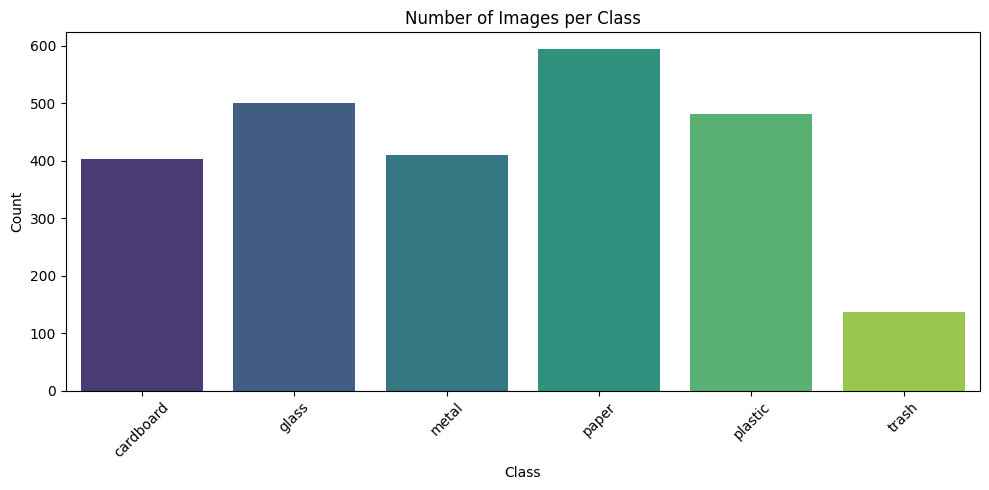

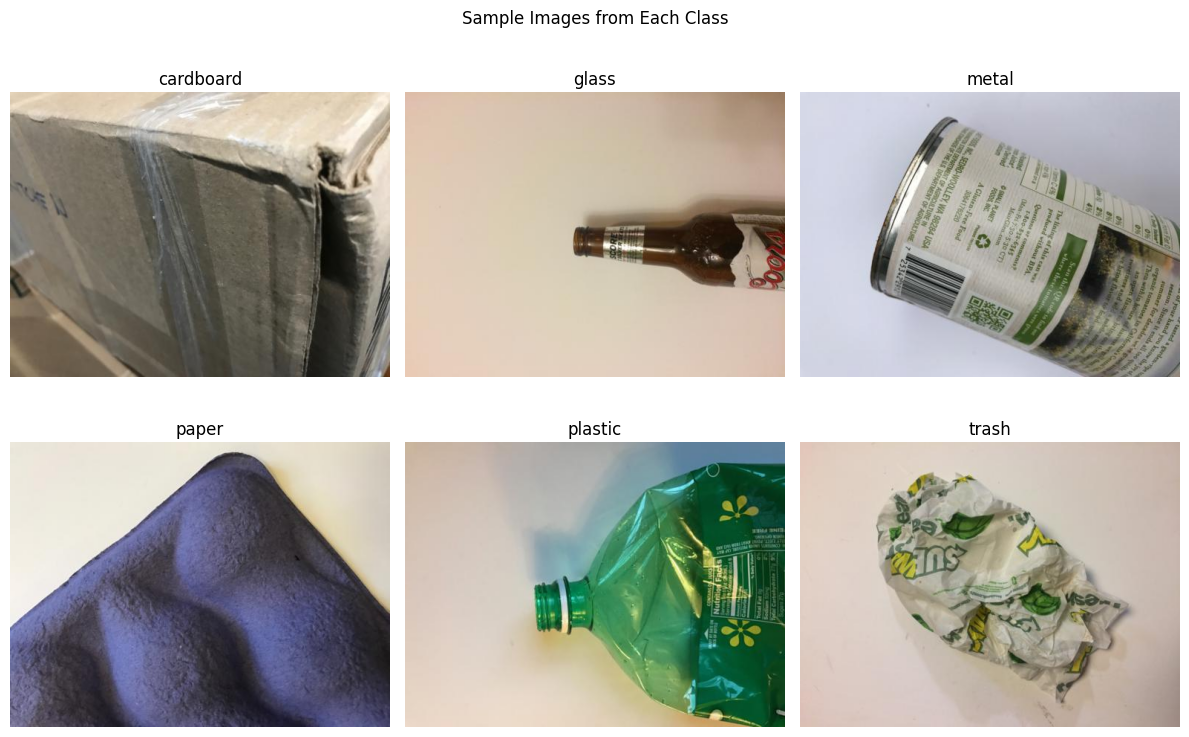

In [5]:
# 1. EXPLORATORY DATA ANALYSIS (EDA)
print("EXPLORATORY DATA ANALYSIS")

# Fix path issue: The extraction often creates a nested 'dataset-resized/dataset-resized' folder
actual_data_path = os.path.join(extract_path, 'dataset-resized')
if not os.path.exists(actual_data_path):
    actual_data_path = extract_path

# Load dataset info into DataFrame
stats = []
for class_name in CLASS_NAMES:
    class_path = os.path.join(actual_data_path, class_name)
    if os.path.isdir(class_path):
        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if files:
            sample_img_path = os.path.join(class_path, files[0])
            with Image.open(sample_img_path) as img:
                width, height = img.size
                mode = img.mode
            stats.append({
                'Class': class_name,
                'Count': len(files),
                'Sample Shape (W, H)': f"{width} x {height}",
                'Mode': mode
            })

df_stats = pd.DataFrame(stats)

if df_stats.empty:
    print("Error: No images found. Please check if the path is correct.")
else:
    print("\nDataset Statistics:")
    print(df_stats.to_string(index=False))

    # Visualise class distribution
    plt.figure(figsize=(10,5))
    sns.barplot(data=df_stats, x='Class', y='Count', palette='viridis')
    plt.title('Number of Images per Class')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Display a few sample images from each class
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(actual_data_path, class_name)
        img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if img_files:
            img_path = os.path.join(class_path, img_files[0])
            img = Image.open(img_path)
            axes[i//3, i%3].imshow(img)
            axes[i//3, i%3].set_title(class_name)
            axes[i//3, i%3].axis('off')
    plt.suptitle("Sample Images from Each Class")
    plt.tight_layout()
    plt.show()

In [6]:
# 2. DATA PREPROCESSING & SPLITTING
print("DATA PREPROCESSING")

# Use the path verified in the EDA step
# (The extraction creates a nested 'dataset-resized/dataset-resized' folder)
processing_data_path = os.path.join(extract_path, 'dataset-resized')
if not os.path.exists(processing_data_path):
    processing_data_path = extract_path

# Load all image paths and labels
image_paths = []
labels = []
for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(processing_data_path, class_name)
    if not os.path.exists(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(class_dir, fname))
            labels.append(idx)

# Convert to numpy arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

# Train / validation / test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

DATA PREPROCESSING
Training samples: 1768
Validation samples: 379
Test samples: 380


In [7]:
# -------------------------------
# 3. DATA LOADING & AUGMENTATION
# -------------------------------
# Preprocessing function: read, decode, resize, normalize
def load_and_preprocess(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0   # scale to [0,1]

    if augment:
        # Data augmentation for training
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        # Random rotation (max 15 degrees)
        angle = tf.random.uniform([], -0.25, 0.25)
        image = tf.image.rot90(image, tf.cast(angle * 4, tf.int32))

    return image, label # Fixed: Moved outside the 'if augment' block

# Create tf.data.Dataset objects
def create_dataset(paths, labels, batch_size, augment=False, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths))
    dataset = dataset.map(lambda p, l: load_and_preprocess(p, l, augment),
                          num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(X_train, y_train, BATCH_SIZE, augment=True, shuffle=True)
val_ds   = create_dataset(X_val, y_val, BATCH_SIZE, augment=False, shuffle=False)
test_ds  = create_dataset(X_test, y_test, BATCH_SIZE, augment=False, shuffle=False)

In [8]:
# -------------------------------
# 4. MODEL DEFINITIONS (3 MODELS)
# -------------------------------
print("\n" + "="*50)
print("MODEL ARCHITECTURES")
print("="*50)

# --- Model 1: Custom CNN (from scratch) ---
def build_custom_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# --- Model 2: MobileNetV2 (transfer learning) ---
def build_mobilenetv2():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False   # freeze base initially
    inputs = keras.Input(shape=(224,224,3))
    x = mobilenet_preprocess(inputs)   # proper preprocessing for MobileNetV2
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model

# --- Model 3: EfficientNetB0 (transfer learning) ---
def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    inputs = keras.Input(shape=(224,224,3))
    x = efficientnet_preprocess(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model


MODEL ARCHITECTURES


In [9]:
# -------------------------------
# 5. TRAINING & EVALUATION FUNCTIONS
# -------------------------------
def compile_and_train(model, model_name):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Callbacks
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    checkpoint = callbacks.ModelCheckpoint(f'best_{model_name}.h5', monitor='val_accuracy', save_best_only=True)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1 )
    return history

def evaluate_model(model, model_name, test_ds):
    # Predict on test set
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    # Collect true labels from test_ds
    y_true = np.concatenate([y for _, y in test_ds], axis=0)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{model_name} - Test Accuracy: {acc:.4f}, Weighted F1: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc, f1, y_true, y_pred


TRAINING CUSTOM CNN
Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2408 - loss: 1.8822  

56/56 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.2969 - loss: 1.7065 - val_accuracy: 0.3852 - val_loss: 1.4389 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3844 - loss: 1.4820  

56/56 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.3767 - loss: 1.4890 - val_accuracy: 0.4169 - val_loss: 1.4320 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4179 - loss: 1.4156  

56/56 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.4248 - loss: 1.4191 - val_accuracy: 0.4354 - val_loss: 1.2794 - learning_rate: 0.0010
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4859 - loss: 1.2821  

56/56 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.4842 - loss: 1.2838 - val_accuracy: 0.5092 - val_loss: 1.2932 - learning_rate: 0.0010
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.5277 - loss: 1.2377 - val_accuracy: 0.5092 - val_loss: 1.2039 - learning_rate: 0.0010
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.5345 - loss: 1.1844 - val_accuracy: 0.5092 - val_loss: 1.2623 - learning_rate: 0.0010
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5408 - loss: 1.1463  

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.8167 - loss: 0.5155 - val_accuracy: 0.7177 - val_loss: 0.8879 - learning_rate: 2.0000e-04
Epoch 17/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.8247 - loss: 0.4966 - val_accuracy: 0.7098 - val_loss: 0.8970 - learning_rate: 2.0000e-04
Epoch 18/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8399 - loss: 0.4377  

56/56 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.8439 - loss: 0.4412 - val_accuracy: 0.7282 - val_loss: 0.8588 - learning_rate: 4.0000e-05
Epoch 19/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.8512 - loss: 0.4382 - val_accuracy: 0.7256 - val_loss: 0.8529 - learning_rate: 4.0000e-05
Epoch 20/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8618 - loss: 0.4063  

56/56 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8626 - loss: 0.4106 - val_accuracy: 0.7361 - val_loss: 0.8629 - learning_rate: 4.0000e-05
Epoch 21/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.8524 - loss: 0.4373 - val_accuracy: 0.7177 - val_loss: 0.8594 - learning_rate: 4.0000e-05
Epoch 22/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8671 - loss: 0.3919 - val_accuracy: 0.7230 - val_loss: 0.8579 - learning_rate: 4.0000e-05
Epoch 23/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.8688 - loss: 0.4006 - val_accuracy: 0.7282 - val_loss: 0.8507 - learning_rate: 8.0000e-06
Epoch 24/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.8716 - loss: 0.3971 - val_accuracy: 0.7309 - val_loss: 0.8475 - learning_rate: 8.0000e-06
Epoch 25/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.8614 - loss: 0.4015 - val_accuracy: 0.7335 - val_loss: 0.8464 - learning_rate: 8.0000e-06
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step


2026-04-06 21:47:55.302636: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Custom CNN - Test Accuracy: 0.7211, Weighted F1: 0.7179

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.84      0.85      0.84        60
       glass       0.69      0.71      0.70        76
       metal       0.75      0.58      0.65        62
       paper       0.71      0.82      0.76        89
     plastic       0.69      0.70      0.69        73
       trash       0.56      0.45      0.50        20

    accuracy                           0.72       380
   macro avg       0.71      0.69      0.69       380
weighted avg       0.72      0.72      0.72       380



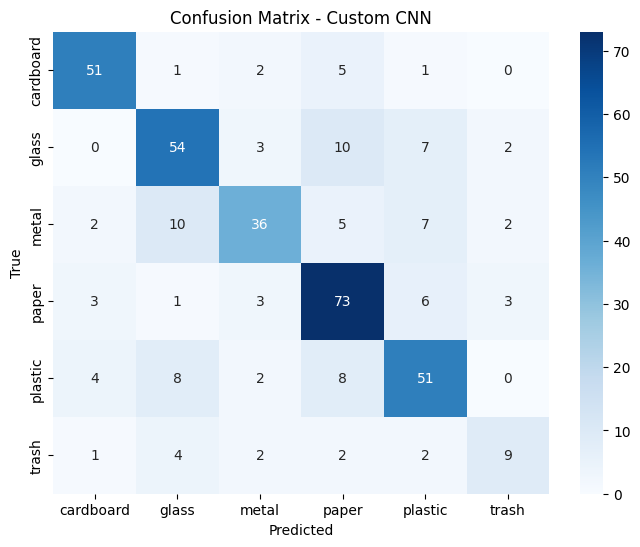


TRAINING MOBILENETV2
Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.1914 - loss: 1.8759 

56/56 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.1991 - loss: 1.8315 - val_accuracy: 0.2348 - val_loss: 1.7200 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.2166 - loss: 1.7777 - val_accuracy: 0.2348 - val_loss: 1.7184 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.2284 - loss: 1.7727 

56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2268 - loss: 1.7768 - val_accuracy: 0.3034 - val_loss: 1.6850 - learning_rate: 0.0010
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.2296 - loss: 1.7521 - val_accuracy: 0.2269 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 958ms/step - accuracy: 0.2319 - loss: 1.7618 - val_accuracy: 0.2137 - val_loss: 1.7327 - learning_rate: 0.0010
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.2270 - loss: 1.7685 

56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2483 - loss: 1.7262 - val_accuracy: 0.3166 - val_loss: 1.6696 - learning_rate: 0.0010
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.2619 - loss: 1.7066 - val_accuracy: 0.2612 - val_loss: 1.6708 - learning_rate: 0.0010
Epoch 8/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.2653 - loss: 1.6912 - val_accuracy: 0.2375 - val_loss: 1.6443 - learning_rate: 2.0000e-04
Epoch 9/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.2698 - loss: 1.6892 - val_accuracy: 0.2718 - val_loss: 1.6435 - learning_rate: 2.0000e-04
Epoch 10/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 789ms/step - accuracy: 0.2670 - loss: 1.6911 - val_accuracy: 0.2639 - val_loss: 1.6391 - learning_rate: 2.0000e-04
Epoch 11/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.2506 - loss: 1.6860 - val_accuracy: 0.2665 - val_loss: 1.6397 - learning_rate: 2.0000e-04
Epoch 12/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.2658 - loss: 1.6862 - val

2026-04-06 22:12:57.196114: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


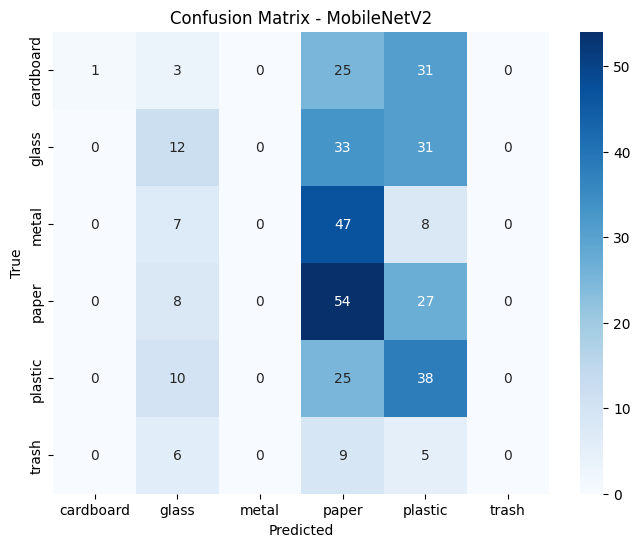


TRAINING EFFICIENTNETB0
Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2152 - loss: 1.7572    

56/56 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.2110 - loss: 1.7476 - val_accuracy: 0.1979 - val_loss: 1.7475 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2209 - loss: 1.7361  

56/56 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.2076 - loss: 1.7368 - val_accuracy: 0.2348 - val_loss: 1.7444 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.2025 - loss: 1.7468 - val_accuracy: 0.2348 - val_loss: 1.7796 - learning_rate: 0.0010
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.2093 - loss: 1.7728 - val_accuracy: 0.2348 - val_loss: 1.7349 - learning_rate: 0.0010
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.2161 - loss: 1.7474 - val_accuracy: 0.2348 - val_loss: 1.7247 - learning_rate: 0.0010
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.2240 - loss: 1.7370 - val_accuracy: 0.1979 - val_loss: 1.7446 - learning_rate: 0.0010
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.2093 - loss: 1.7439 - val_accuracy: 0.2348 - val_loss: 1.7258 - learning_rate: 0.0010
Epoch 8/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.2070 - loss: 1.7506 - val_accuracy: 0.187

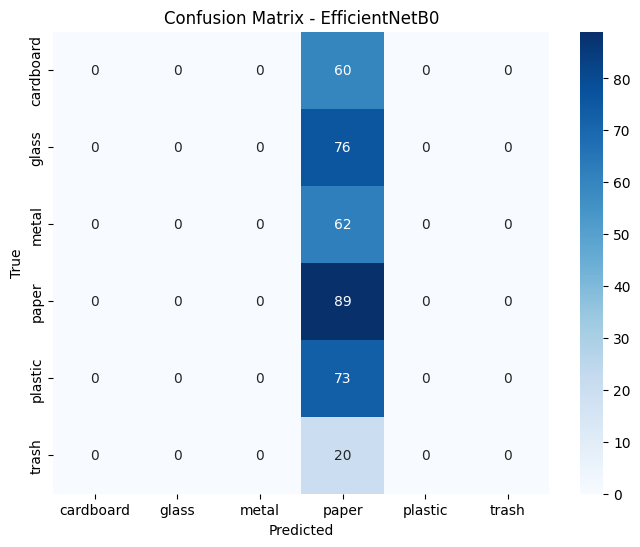

In [10]:
# -------------------------------
# 6. TRAIN ALL THREE MODELS & COMPARE
# -------------------------------
results = {}

# Model 1: Custom CNN
print("\n" + "="*50)
print("TRAINING CUSTOM CNN")
print("="*50)
model_cnn = build_custom_cnn()
history_cnn = compile_and_train(model_cnn, "CustomCNN")
acc_cnn, f1_cnn, _, _ = evaluate_model(model_cnn, "Custom CNN", test_ds)
results["Custom CNN"] = {"Accuracy": acc_cnn, "F1 Score": f1_cnn, "History": history_cnn}

# Model 2: MobileNetV2
print("\n" + "="*50)
print("TRAINING MOBILENETV2")
print("="*50)
model_mob = build_mobilenetv2()
history_mob = compile_and_train(model_mob, "MobileNetV2")
acc_mob, f1_mob, _, _ = evaluate_model(model_mob, "MobileNetV2", test_ds)
results["MobileNetV2"] = {"Accuracy": acc_mob, "F1 Score": f1_mob, "History": history_mob}

# Model 3: EfficientNetB0
print("\n" + "="*50)
print("TRAINING EFFICIENTNETB0")
print("="*50)
model_eff = build_efficientnet()
history_eff = compile_and_train(model_eff, "EfficientNetB0")
acc_eff, f1_eff, _, _ = evaluate_model(model_eff, "EfficientNetB0", test_ds)
results["EfficientNetB0"] = {"Accuracy": acc_eff, "F1 Score": f1_eff, "History": history_eff}


MODEL COMPARISON
         Model  Test Accuracy  Weighted F1 Score
    Custom CNN       0.721053           0.717866
   MobileNetV2       0.276316           0.202763
EfficientNetB0       0.234211           0.088890

🏆 BEST MODEL: Custom CNN (Test Accuracy = 0.7211)


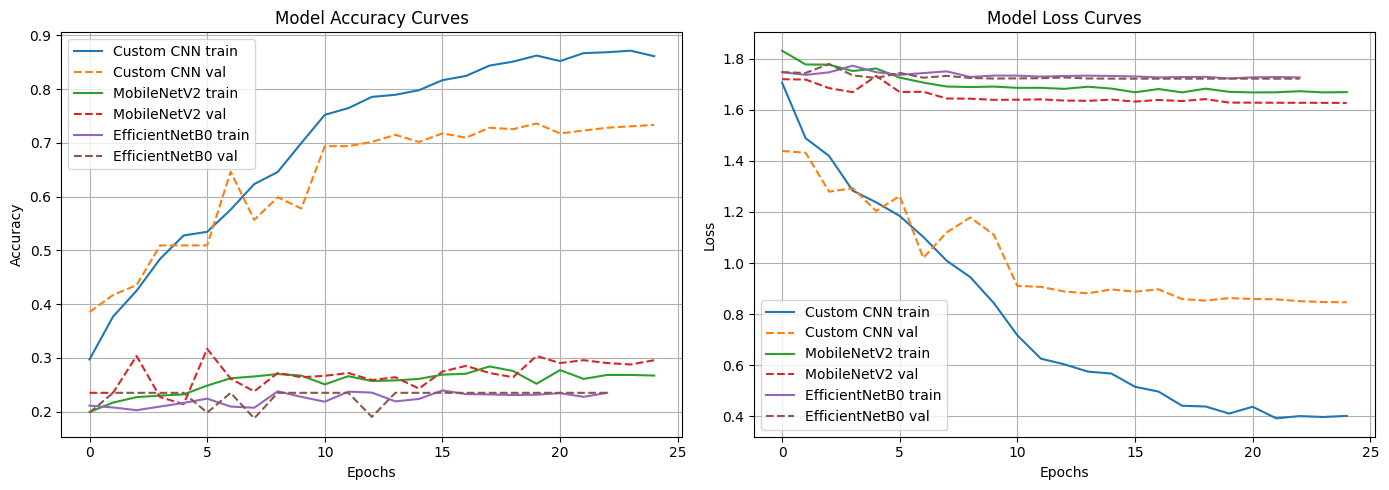

FINAL EVALUATION OF BEST MODEL: Custom CNN
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step

Custom CNN - Test Accuracy: 0.7211, Weighted F1: 0.7179

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.84      0.85      0.84        60
       glass       0.69      0.71      0.70        76
       metal       0.75      0.58      0.65        62
       paper       0.71      0.82      0.76        89
     plastic       0.69      0.70      0.69        73
       trash       0.56      0.45      0.50        20

    accuracy                           0.72       380
   macro avg       0.71      0.69      0.69       380
weighted avg       0.72      0.72      0.72       380



2026-04-06 22:45:45.375509: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


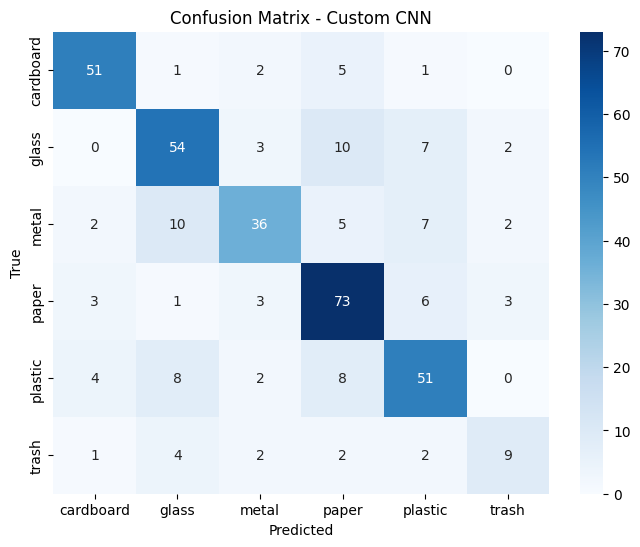


✅ Best model saved as 'best_garbage_classifier.h5'


In [11]:
# -------------------------------
# 7. COMPARE & SELECT BEST MODEL
# -------------------------------
print("MODEL COMPARISON")
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Test Accuracy": [results[m]["Accuracy"] for m in results],
    "Weighted F1 Score": [results[m]["F1 Score"] for m in results]
})
print(comparison_df.to_string(index=False))

# Select best based on test accuracy
best_model_name = comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Model"]
print(f"\n🏆 BEST MODEL: {best_model_name} (Test Accuracy = {comparison_df['Test Accuracy'].max():.4f})")
# Plot training curves for comparison
plt.figure(figsize=(14,5))
for i, metric in enumerate(['accuracy', 'loss']):
    plt.subplot(1,2,i+1)
    for m in results:
        hist = results[m]["History"]
        plt.plot(hist.history[metric], label=f'{m} train')
        plt.plot(hist.history[f'val_{metric}'], linestyle='--', label=f'{m} val')
    plt.title(f'Model {metric.capitalize()} Curves')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()
# Final evaluation of the best model on test set (again with detailed report)
if best_model_name == "Custom CNN":
    best_model = model_cnn
elif best_model_name == "MobileNetV2":
    best_model = model_mob
else:
    best_model = model_eff

print(f"FINAL EVALUATION OF BEST MODEL: {best_model_name}")
_, _, y_true_best, y_pred_best = evaluate_model(best_model, best_model_name, test_ds)

# Optional: save the best model for later use
best_model.save('best_garbage_classifier.h5')
print("\n✅ Best model saved as 'best_garbage_classifier.h5'")